========== FIRST 5 ROWS ==========
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction Standa

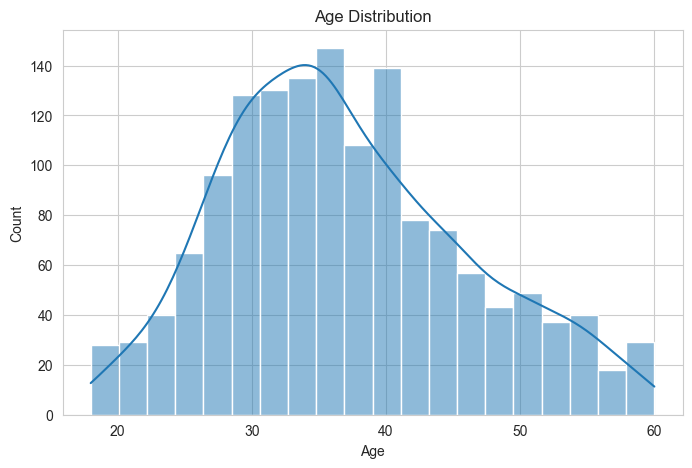

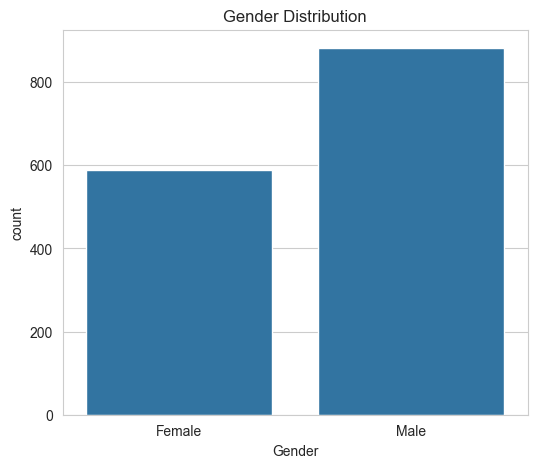

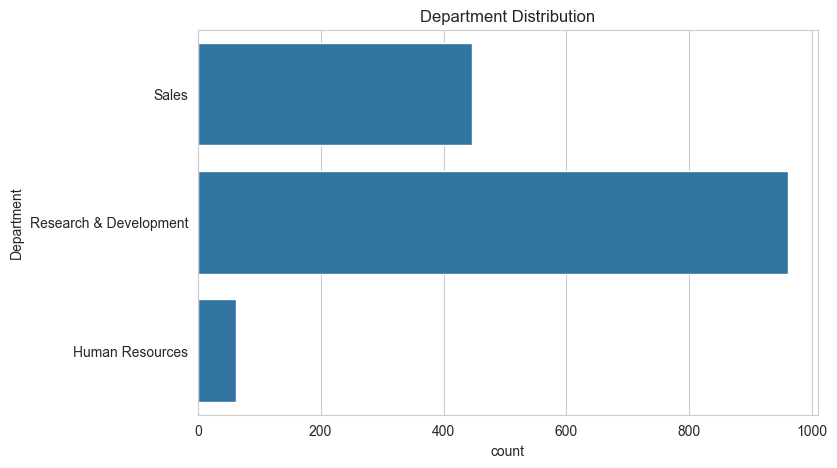

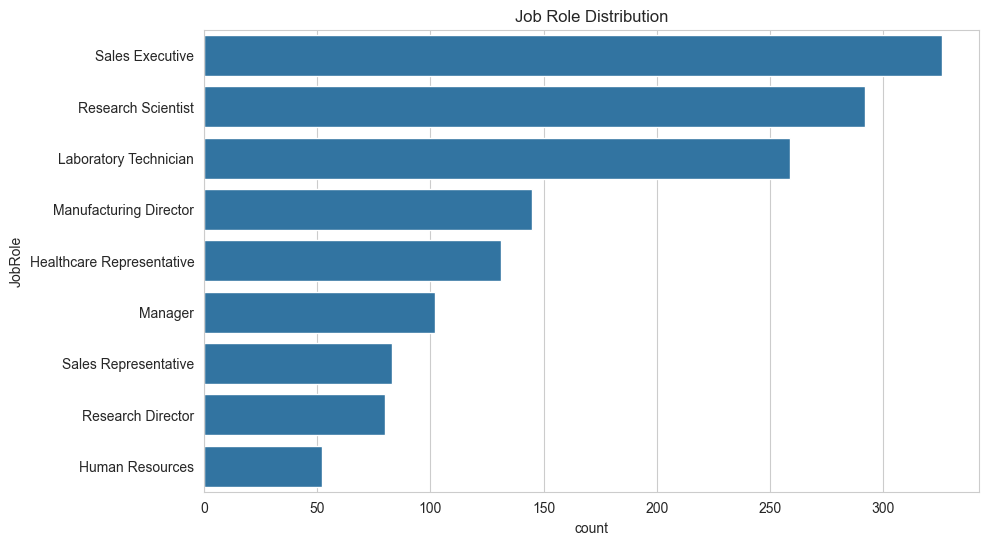

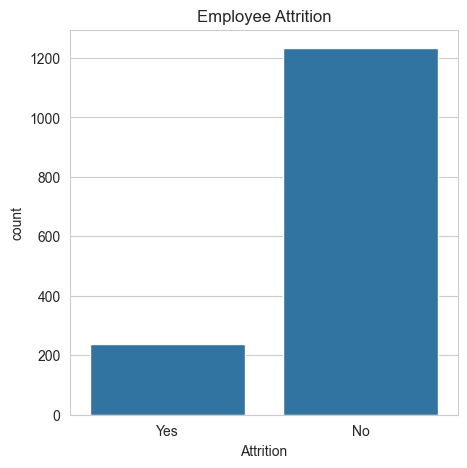

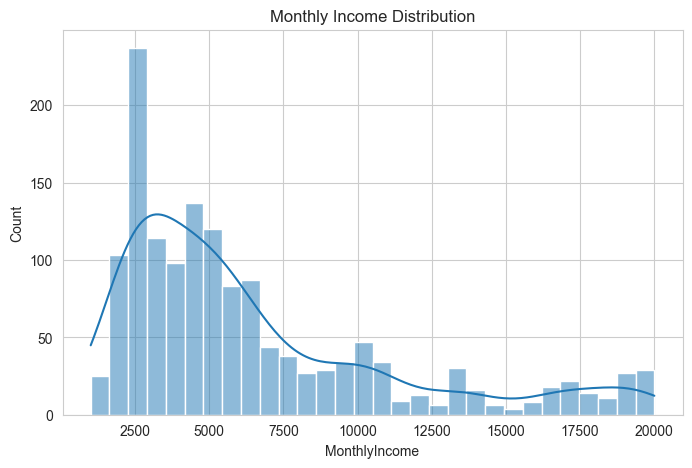

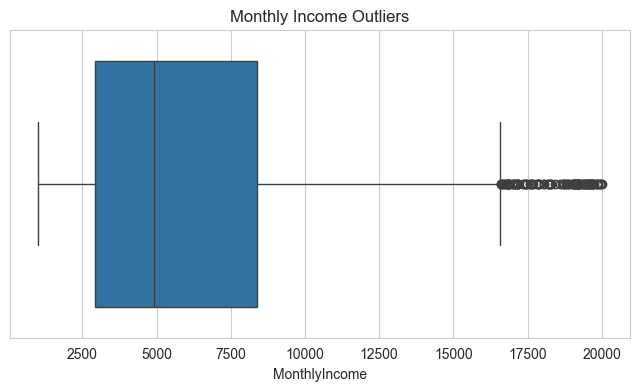

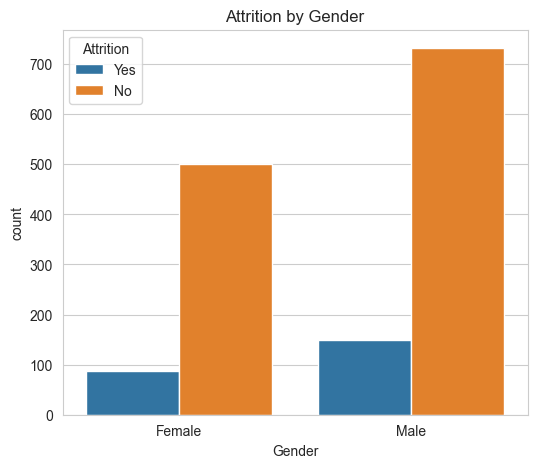

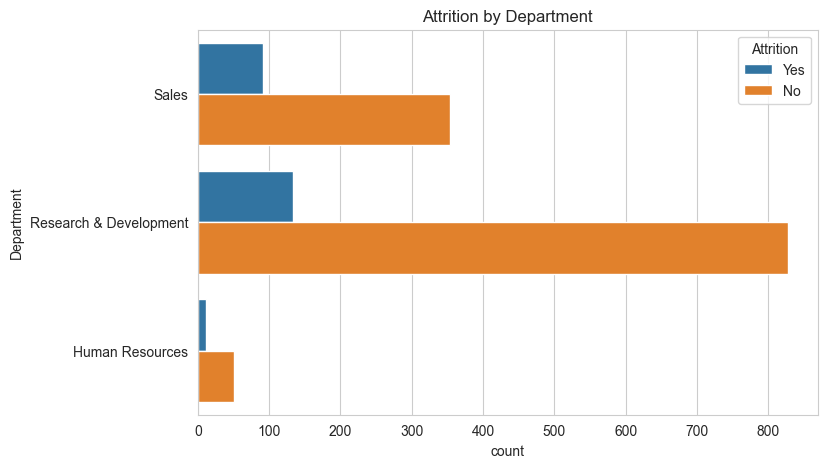

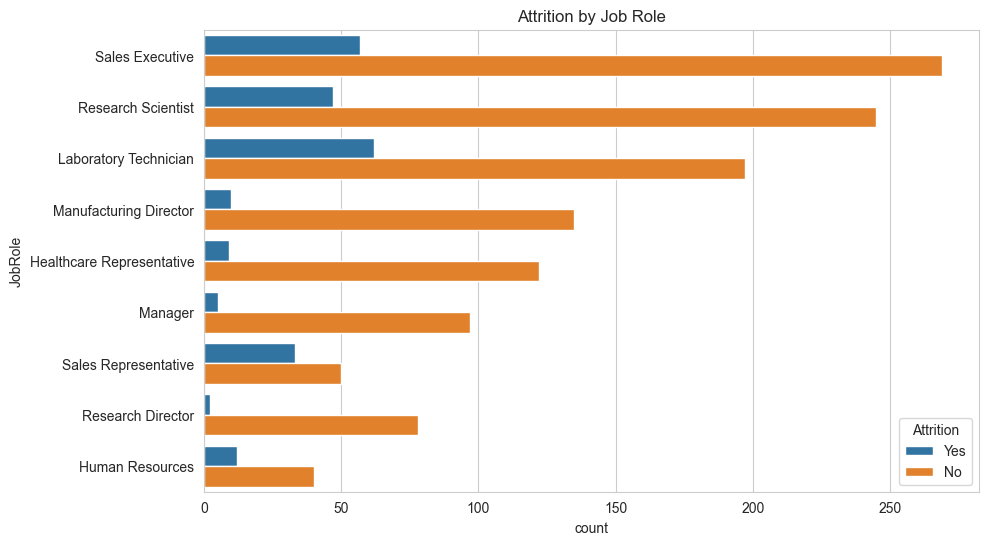

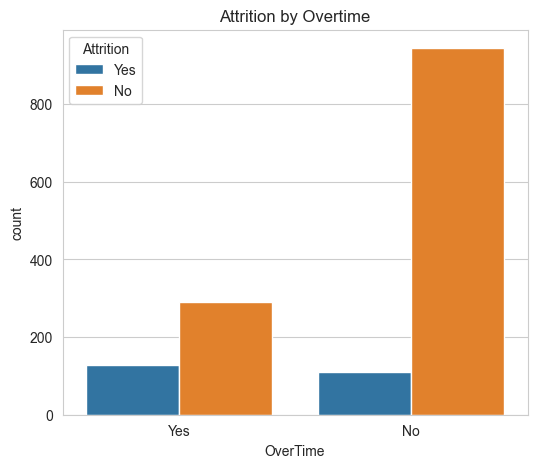

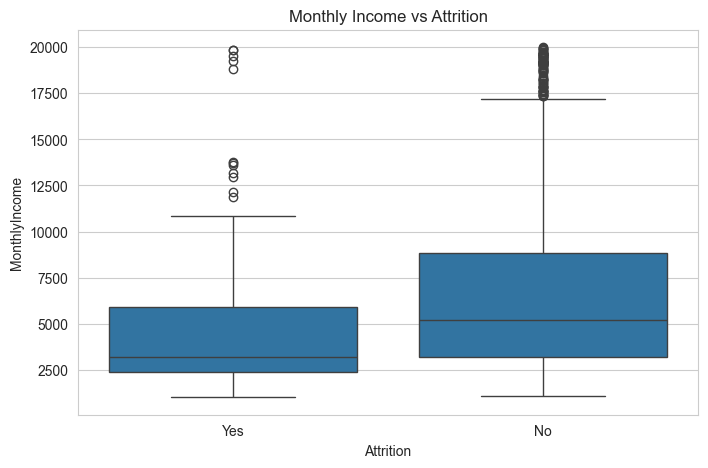

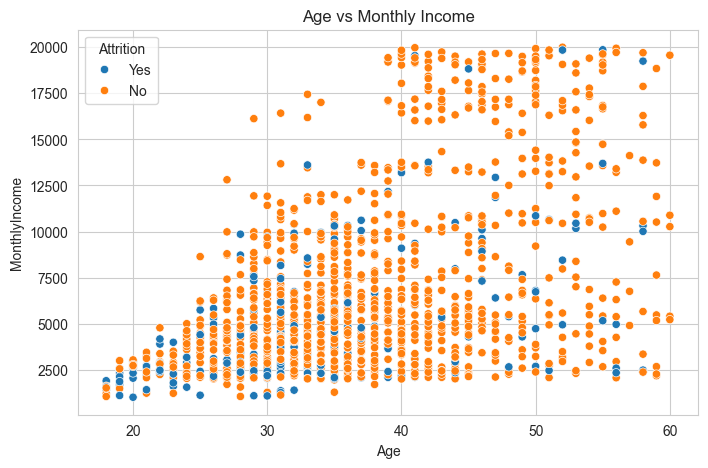

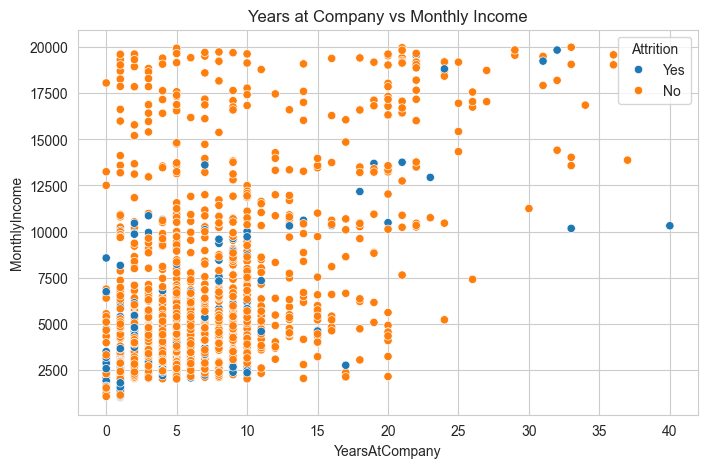

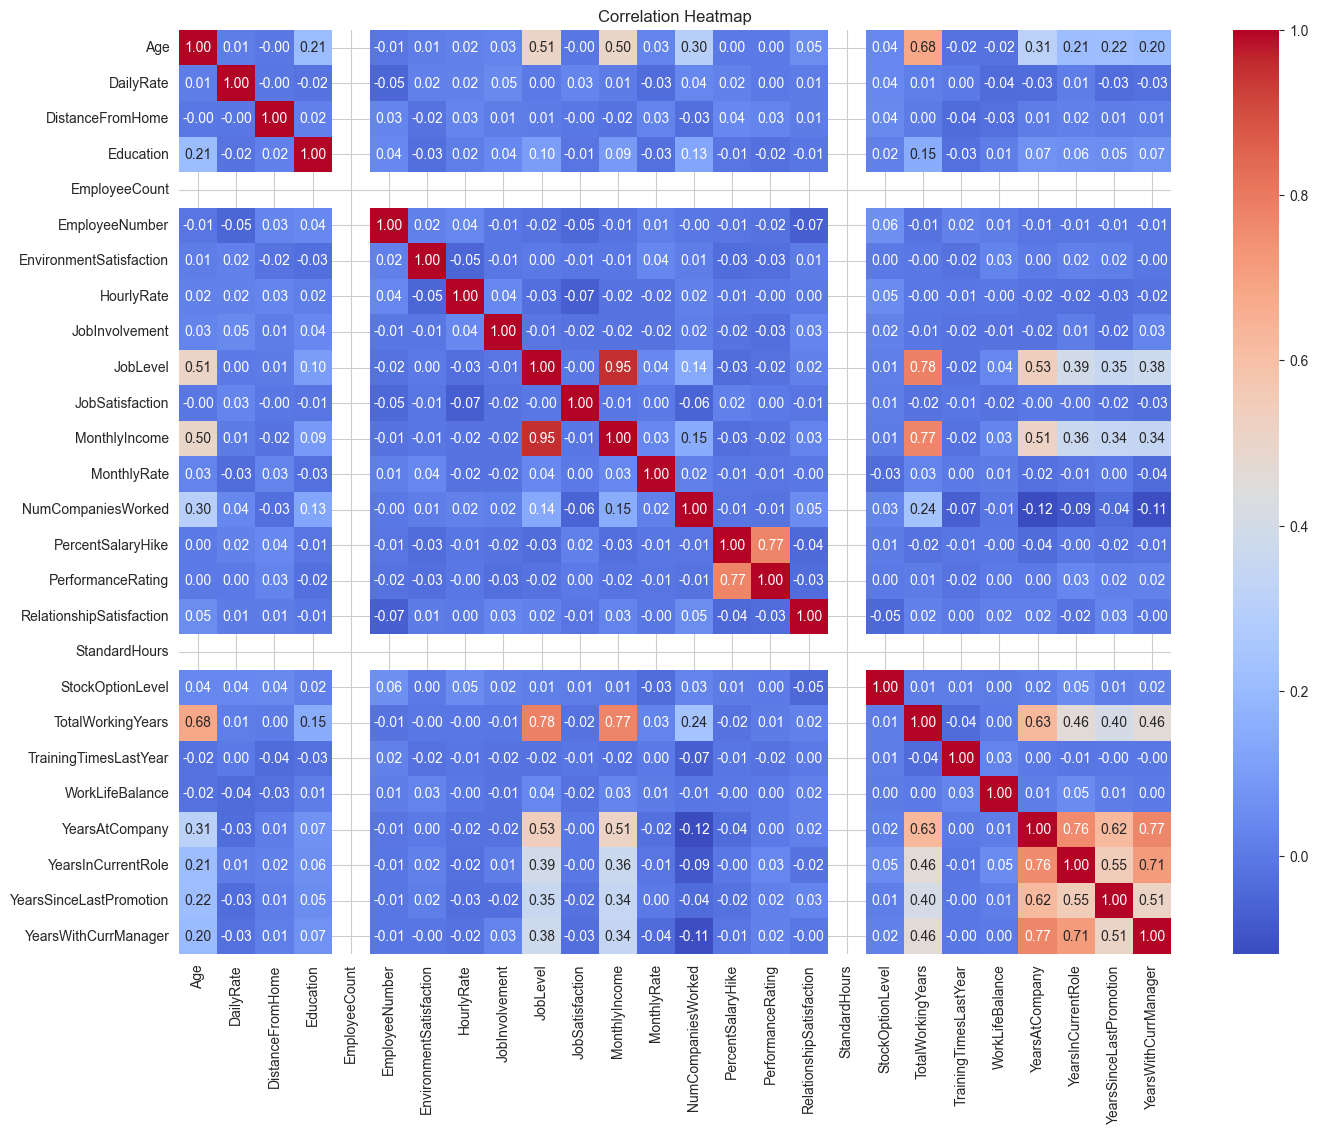


========== CORRELATION MATRIX ==========
                               Age  DailyRate  DistanceFromHome  Education  \
Age                       1.000000   0.010661         -0.001686   0.208034   
DailyRate                 0.010661   1.000000         -0.004985  -0.016806   
DistanceFromHome         -0.001686  -0.004985          1.000000   0.021042   
Education                 0.208034  -0.016806          0.021042   1.000000   
EmployeeCount                  NaN        NaN               NaN        NaN   
EmployeeNumber           -0.010145  -0.050990          0.032916   0.042070   
EnvironmentSatisfaction   0.010146   0.018355         -0.016075  -0.027128   
HourlyRate                0.024287   0.023381          0.031131   0.016775   
JobInvolvement            0.029820   0.046135          0.008783   0.042438   
JobLevel                  0.509604   0.002966          0.005303   0.101589   
JobSatisfaction          -0.004892   0.030571         -0.003669  -0.011296   
MonthlyIncome         

In [2]:
# =====================================
# Exploratory Data Analysis (EDA)
# HR Employee Attrition Dataset
# =====================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Graph Style
sns.set_style("whitegrid")

# -------------------------------------
# Load Dataset
# -------------------------------------
df = pd.read_csv("D:/SCT_DA_3/WA_Fn-UseC_-HR-Employee-Attrition.csv")

# -------------------------------------
# Dataset Overview
# -------------------------------------
print("========== FIRST 5 ROWS ==========")
print(df.head())

print("\n========== LAST 5 ROWS ==========")
print(df.tail())

print("\n========== SHAPE ==========")
print(df.shape)

print("\n========== COLUMNS ==========")
print(df.columns)

print("\n========== DATA TYPES ==========")
print(df.info())

print("\n========== STATISTICAL SUMMARY ==========")
print(df.describe())

# -------------------------------------
# Missing Values
# -------------------------------------
print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())

# -------------------------------------
# Duplicate Values
# -------------------------------------
print("\n========== DUPLICATES ==========")
print(df.duplicated().sum())

# Remove duplicates if present
df.drop_duplicates(inplace=True)

# -------------------------------------
# Unique Values
# -------------------------------------
print("\n========== UNIQUE VALUES ==========")

for col in df.columns:
    print(f"{col} : {df[col].nunique()}")

# =====================================
# UNIVARIATE ANALYSIS
# =====================================

# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

# Gender Count
plt.figure(figsize=(6,5))
sns.countplot(x="Gender", data=df)
plt.title("Gender Distribution")
plt.show()

# Department Count
plt.figure(figsize=(8,5))
sns.countplot(y="Department", data=df)
plt.title("Department Distribution")
plt.show()

# Job Role
plt.figure(figsize=(10,6))
sns.countplot(y="JobRole", data=df)
plt.title("Job Role Distribution")
plt.show()

# Attrition
plt.figure(figsize=(5,5))
sns.countplot(x="Attrition", data=df)
plt.title("Employee Attrition")
plt.show()

# Monthly Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyIncome"], bins=30, kde=True)
plt.title("Monthly Income Distribution")
plt.show()

# Boxplot for Monthly Income
plt.figure(figsize=(8,4))
sns.boxplot(x=df["MonthlyIncome"])
plt.title("Monthly Income Outliers")
plt.show()

# =====================================
# BIVARIATE ANALYSIS
# =====================================

# Attrition by Gender
plt.figure(figsize=(6,5))
sns.countplot(x="Gender", hue="Attrition", data=df)
plt.title("Attrition by Gender")
plt.show()

# Attrition by Department
plt.figure(figsize=(8,5))
sns.countplot(y="Department", hue="Attrition", data=df)
plt.title("Attrition by Department")
plt.show()

# Attrition by Job Role
plt.figure(figsize=(10,6))
sns.countplot(y="JobRole", hue="Attrition", data=df)
plt.title("Attrition by Job Role")
plt.show()

# Attrition by Overtime
plt.figure(figsize=(6,5))
sns.countplot(x="OverTime", hue="Attrition", data=df)
plt.title("Attrition by Overtime")
plt.show()

# Monthly Income vs Attrition
plt.figure(figsize=(8,5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df)
plt.title("Monthly Income vs Attrition")
plt.show()

# Age vs Monthly Income
plt.figure(figsize=(8,5))
sns.scatterplot(x="Age", y="MonthlyIncome", hue="Attrition", data=df)
plt.title("Age vs Monthly Income")
plt.show()

# Years at Company vs Monthly Income
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="YearsAtCompany",
    y="MonthlyIncome",
    hue="Attrition",
    data=df
)
plt.title("Years at Company vs Monthly Income")
plt.show()

# =====================================
# CORRELATION ANALYSIS
# =====================================

numeric_df = df.select_dtypes(include=["int64","float64"])

correlation = numeric_df.corr()

plt.figure(figsize=(16,12))
sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

# =====================================
# TOP CORRELATIONS
# =====================================

corr_matrix = numeric_df.corr()

print("\n========== CORRELATION MATRIX ==========")
print(corr_matrix)

# =====================================
# DESCRIPTIVE STATISTICS
# =====================================

print("\nAverage Age :", df["Age"].mean())

print("Maximum Age :", df["Age"].max())

print("Minimum Age :", df["Age"].min())

print("Average Monthly Income :", df["MonthlyIncome"].mean())

print("Maximum Monthly Income :", df["MonthlyIncome"].max())

print("Minimum Monthly Income :", df["MonthlyIncome"].min())

# =====================================
# Attrition Percentage
# =====================================

attrition_percentage = (
    df["Attrition"]
    .value_counts(normalize=True) * 100
)

print("\n========== ATTRITION PERCENTAGE ==========")
print(attrition_percentage)

# =====================================
# Department Wise Average Salary
# =====================================

print("\n========== DEPARTMENT WISE AVERAGE SALARY ==========")

print(
    df.groupby("Department")["MonthlyIncome"].mean()
)

# =====================================
# Job Role Wise Average Salary
# =====================================

print("\n========== JOB ROLE WISE AVERAGE SALARY ==========")

print(
    df.groupby("JobRole")["MonthlyIncome"].mean()
)

# =====================================
# Overtime Count
# =====================================

print("\n========== OVERTIME ==========")

print(df["OverTime"].value_counts())

# =====================================
# Marital Status
# =====================================

print("\n========== MARITAL STATUS ==========")

print(df["MaritalStatus"].value_counts())

# =====================================
# Education Level
# =====================================

print("\n========== EDUCATION LEVEL ==========")

print(df["Education"].value_counts())

# =====================================
# End
# =====================================

print("\nEDA Completed Successfully!")